In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")

In [13]:
import os
import pandas as pd
import numpy as np

os.chdir(r"C:\Users\pc\climate-challenge-week0")

df = pd.read_csv("data/tanzania.csv", sep="\t")
df["Country"] = "tanzania"

# Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# Parse date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,tanzania,2015-01-05,1


In [14]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Summary stats
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [15]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
print(missing_report[missing_report["Percent"] > 0])

Empty DataFrame
Columns: [Missing, Percent]
Index: []


In [16]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(stats.zscore, nan_policy="omit")
outliers = (z_scores.abs() > 3)
print("Outlier counts per column:")
print(outliers.sum())

Outlier counts per column:
T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64


In [17]:
# Forward fill weather variables
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("data/tanzania_clean.csv", index=False)
print("Cleaned data exported.")

Cleaned data exported.


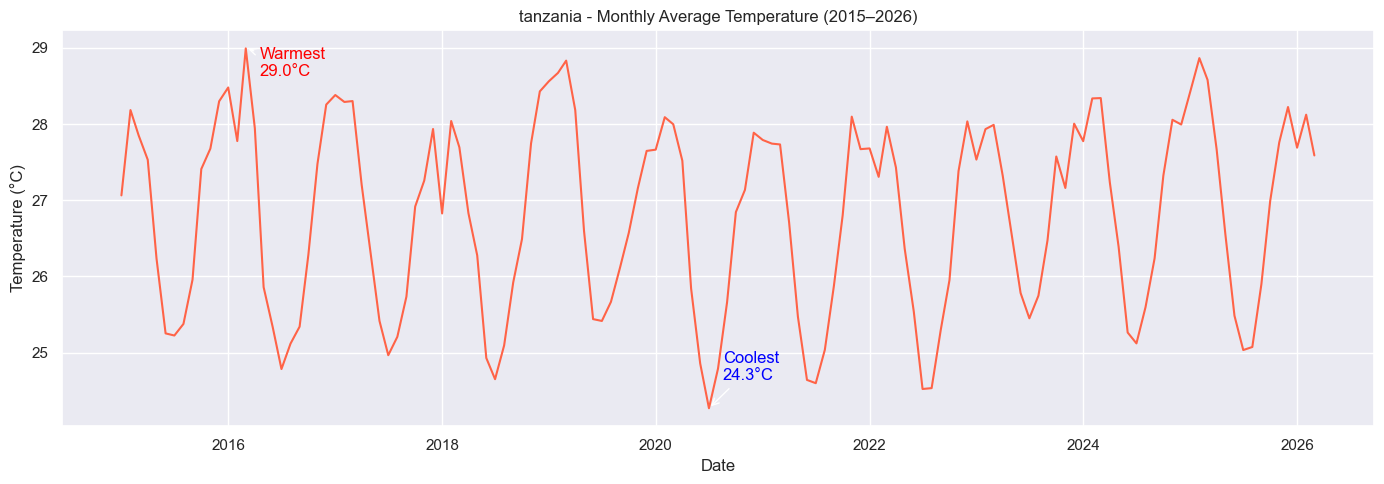

In [18]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato")

# Annotate warmest and coolest
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C', 
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(10, -20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C', 
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(10, 20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="blue")

plt.title("tanzania - Monthly Average Temperature (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("notebooks/tanzania_temp_trend.png")
plt.show()

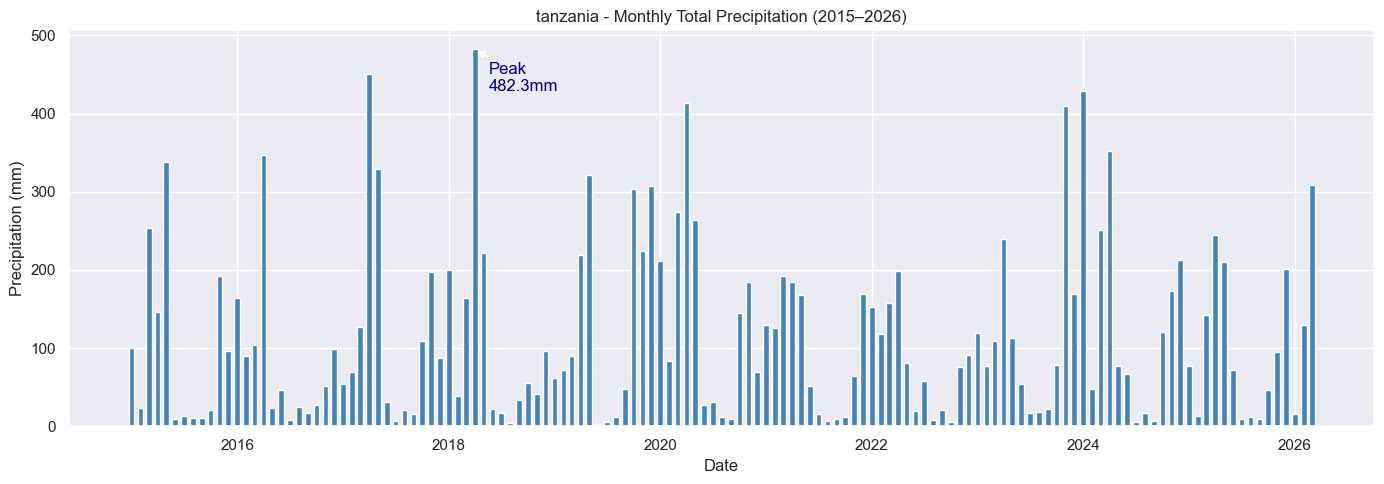

In [19]:
monthly_precip = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_precip["Date"] = pd.to_datetime(monthly_precip[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_precip["Date"], monthly_precip["PRECTOTCORR"], color="steelblue", width=20)

peak = monthly_precip.loc[monthly_precip["PRECTOTCORR"].idxmax()]
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(10, -30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="navy")

plt.title("tanzania - Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.savefig("notebooks/tanzania_precip.png")
plt.show()

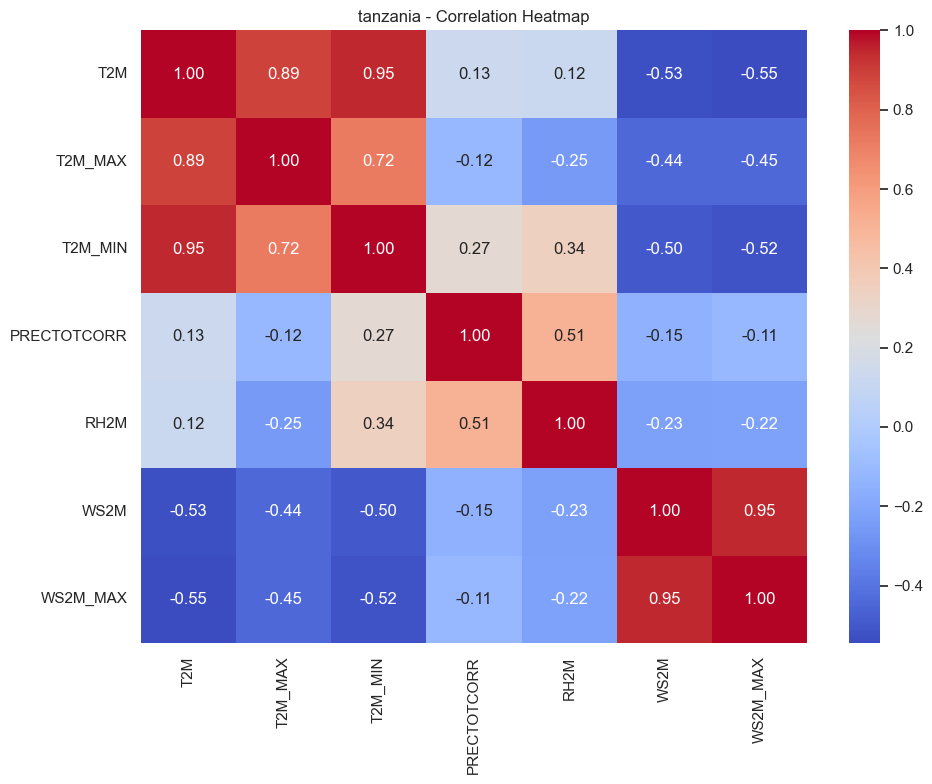

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("tanzania - Correlation Heatmap")
plt.tight_layout()
plt.savefig("notebooks/tanzania_corr.png")
plt.show()

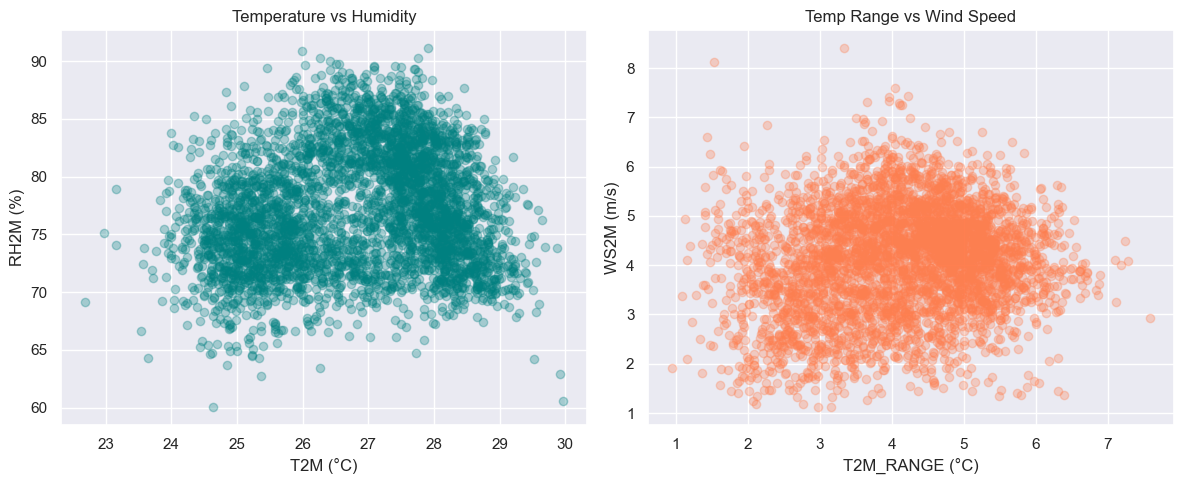

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="teal")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].set_title("Temperature vs Humidity")

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="coral")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].set_title("Temp Range vs Wind Speed")

plt.tight_layout()
plt.savefig("notebooks/tanzania_scatter.png")
plt.show()

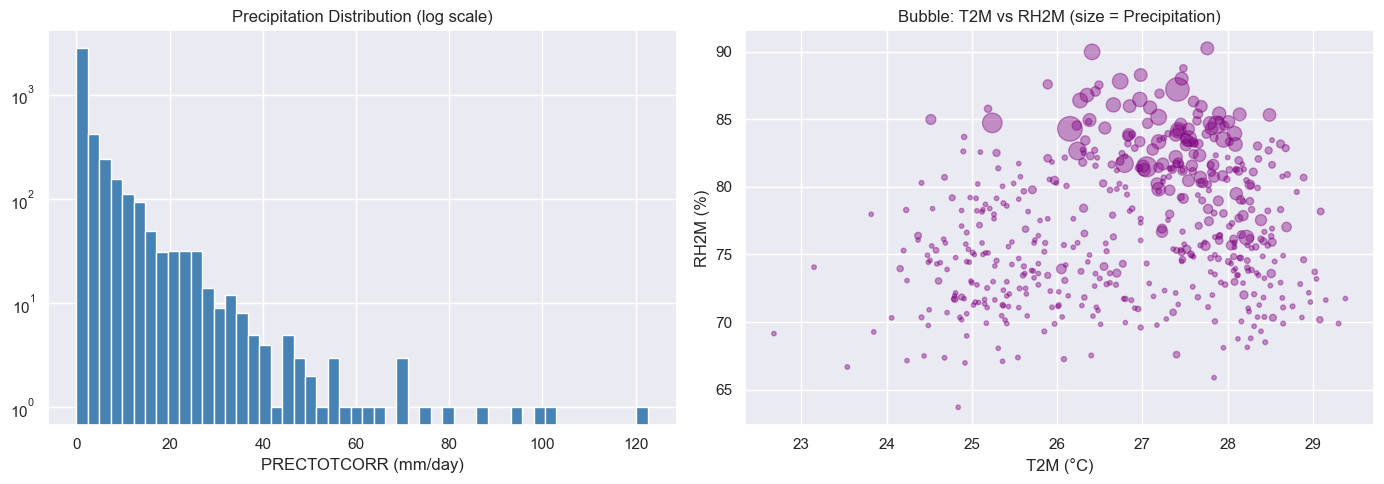

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale
axes[0].hist(df["PRECTOTCORR"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Precipitation Distribution (log scale)")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")

# Bubble chart
sample = df.sample(500, random_state=42)
axes[1].scatter(sample["T2M"], sample["RH2M"],
                s=sample["PRECTOTCORR"].fillna(0) * 5 + 10,
                alpha=0.4, color="purple")
axes[1].set_xlabel("T2M (°C)")
axes[1].set_ylabel("RH2M (%)")
axes[1].set_title("Bubble: T2M vs RH2M (size = Precipitation)")

plt.tight_layout()
plt.savefig("notebooks/tanzania_dist.png")
plt.show()